<a href="https://colab.research.google.com/github/YashviGupta15/ai-ml-notes/blob/main/Full_Self_Attention.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## From Encoder–Decoder Attention to Self-Attention

In encoder–decoder attention, we had:

- Queries (Q) coming from the **decoder**
- Keys (K) and Values (V) coming from the **encoder**

This means:

> The decoder attends to the encoder outputs to gather relevant information.

---

### Limitation

This setup is **asymmetric**:

- Interaction happens **across sequences** (decoder ↔ encoder)
- But NOT **within the same sequence**

---

### Key Idea of Self-Attention

Self-attention removes this restriction.

Now:

- Queries, Keys, and Values all come from the **same input sequence**

So:

> Each token attends to every other token (including itself)

---

### Conceptual Shift

| Mechanism | Query Source | Key/Value Source | Interaction |
|----------|-------------|------------------|------------|
| Encoder–Decoder Attention | Decoder | Encoder | Cross-sequence |
| Self-Attention | Same sequence | Same sequence | Within-sequence |

---

### Intuition

Consider the sentence:

"The movie was not good"

The word **"good"** should:

- Look at **"not"** → to understand negation
- Look at **"movie"** → to understand context

So:

> Meaning of a word is **contextual**, not independent

## Mathematical Representation

Let the input sequence be represented as:

$$
X \in \mathbb{R}^{n \times d_{model}}
$$

Where:

- $n$ = number of tokens
- $d_{model}$ = embedding dimension

---

In self-attention:

$$
Q = X W_Q
$$

$$
K = X W_K
$$

$$
V = X W_V
$$

---

So all three:

- Query (Q)
- Key (K)
- Value (V)

are derived from the **same input matrix $X$**

---

### Interpretation

For token $i$:

- $q_i$ = what the token is looking for
- $k_j$ = what another token contains
- $v_j$ = information carried by that token

In [ ]:
# GLOBAL SETUP
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

def softmax(x):
    x = x - np.max(x)
    exp_x = np.exp(x)
    return exp_x / np.sum(exp_x)

def row_softmax(matrix):
    matrix = matrix - np.max(matrix, axis=1, keepdims=True)
    exp_matrix = np.exp(matrix)
    return exp_matrix / np.sum(exp_matrix, axis=1, keepdims=True)

# Toy sentence
tokens = ["The", "movie", "was", "not", "good"]

# Embedding matrix X (n=5, d_model=4)
X = np.random.randn(5, 4)

print("Tokens:", tokens)
print("Shape of X:", X.shape)
print("\nEmbedding Matrix X:\n", X)

Tokens: ['The', 'movie', 'was', 'not', 'good']
Shape of X: (5, 4)

Embedding Matrix X:
 [[ 0.49671415 -0.1382643   0.64768854  1.52302986]
 [-0.23415337 -0.23413696  1.57921282  0.76743473]
 [-0.46947439  0.54256004 -0.46341769 -0.46572975]
 [ 0.24196227 -1.91328024 -1.72491783 -0.56228753]
 [-1.01283112  0.31424733 -0.90802408 -1.4123037 ]]


## Observation

- We created a matrix:

$$
X \in \mathbb{R}^{5 \times 4}
$$

- Each row corresponds to a **token embedding**
- Currently, embeddings are **independent**

---

### Key Insight

At this stage:

> The word "good" has no awareness of "not"

So the model cannot understand:

"not good" ≠ "good"

---

### What is Missing?

- No interaction between tokens
- No context awareness
- No dependency modeling

This is exactly what **self-attention will solve**

## Concept Check

1. In encoder–decoder attention, where do Q, K, V come from?

2. In self-attention, why do we use the same matrix $X$ for Q, K, V?

3. What is the limitation of treating embeddings independently?

4. In the sentence:

   "The movie was not good"

   Why must "good" attend to "not"?

## Bridge to Next Section

Now we understand:

> Self-attention enables interaction within the same sequence

Next, we go deeper into:

- How the input matrix $X$ is structured
- What each row represents
- Why shape tracking is critical

---

Next Section:

**Input Matrix $X$ and Token Embedding Matrix Shape**

## Input Matrix $X$ and Token Embedding Structure

We start with a sequence of tokens:

"The movie was not good"

Each token is converted into a vector using an embedding mechanism.

---

### From Tokens to Matrix

Instead of treating tokens individually, we stack them into a matrix:

$$
X =
\begin{bmatrix}
x_1 \\
x_2 \\
x_3 \\
x_4 \\
x_5
\end{bmatrix}
$$

---

### Key Idea

- Each row = embedding of one token
- Entire sentence = a **matrix representation**

---

### Why This Matters

This matrix form enables:

- Vectorized computation
- Parallel processing
- Efficient attention computation

---

### Important Observation

At this stage:

> Tokens are represented numerically, but still **do not interact**

Each $x_i$ is independent.

## Mathematical Formulation

Let:

$$
X \in \mathbb{R}^{n \times d_{model}}
$$

Where:

- $n$ = number of tokens (sequence length)
- $d_{model}$ = embedding dimension

---

### For Our Example:

$$
n = 5, \quad d_{model} = 4
$$

So:

$$
X \in \mathbb{R}^{5 \times 4}
$$

---

### Row-wise Representation

Each token embedding:

$$
x_i \in \mathbb{R}^{d_{model}}
$$

---

### Expanded View

$$
X =
\begin{bmatrix}
x_{1,1} & x_{1,2} & x_{1,3} & x_{1,4} \\
x_{2,1} & x_{2,2} & x_{2,3} & x_{2,4} \\
x_{3,1} & x_{3,2} & x_{3,3} & x_{3,4} \\
x_{4,1} & x_{4,2} & x_{4,3} & x_{4,4} \\
x_{5,1} & x_{5,2} & x_{5,3} & x_{5,4}
\end{bmatrix}
$$

---

### Interpretation

- Row index → token position
- Column index → feature dimension

---

### Critical Insight

Matrix $X$ is the **starting point** for all attention computations.

In [ ]:
# Reusing X from previous section

print("Tokens:", tokens)
print("\nShape of X:", X.shape)

print("\nRow-wise embeddings:")
for i, token in enumerate(tokens):
    print(f"{token} -> {X[i]}")

# Check independence (no interaction yet)
print("\nDot product between 'good' and 'not':")
good_index = tokens.index("good")
not_index = tokens.index("not")

dot_product = np.dot(X[good_index], X[not_index])
print("Dot Product:", dot_product)

Tokens: ['The', 'movie', 'was', 'not', 'good']

Shape of X: (5, 4)

Row-wise embeddings:
The -> [ 0.49671415 -0.1382643   0.64768854  1.52302986]
movie -> [-0.23415337 -0.23413696  1.57921282  0.76743473]
was -> [-0.46947439  0.54256004 -0.46341769 -0.46572975]
not -> [ 0.24196227 -1.91328024 -1.72491783 -0.56228753]
good -> [-1.01283112  0.31424733 -0.90802408 -1.4123037 ]

Dot product between 'good' and 'not':
Dot Product: 1.5140775469995646


## Observations

- Each token is mapped to a vector in $\mathbb{R}^4$
- The matrix shape is:

$$
X \in \mathbb{R}^{5 \times 4}
$$

---

### What We Just Saw

- Rows are independent representations
- Even though we computed a dot product:

$$
x_{\text{good}} \cdot x_{\text{not}}
$$

It is:

- Not normalized
- Not contextual
- Not learned dynamically

---

### Key Limitation

> This dot product is **static**

It does NOT depend on:

- Sentence structure
- Contextual importance
- Position relevance

---

### Why This is a Problem

The model cannot distinguish:

- "good movie"
- "not good movie"

because embeddings are fixed.

---

### What We Need

A mechanism where:

- Each token representation is **updated using other tokens**

That mechanism = **Self-Attention**

## Concept Check

1. What does each row of matrix $X$ represent?

2. Why do we use a matrix instead of processing tokens one by one?

3. What is the shape of $X$ in our example?

4. Why is the dot product between two token embeddings insufficient for context modeling?

5. What is missing in $X$ that self-attention will introduce?

## Bridge to Next Section

We now clearly understand:

- Input matrix $X$
- Shape and structure
- Its limitation (no interaction)

---

Next, we introduce **learnable transformations**:

We will project $X$ into:

- Query space
- Key space
- Value space

---

Next Section:

## Query, Key, Value Projections

## Query, Key, Value Projections

In self-attention, we do not directly use the input matrix $X$ for attention.

Instead, we create three different representations from the same input:

- Query matrix $Q$
- Key matrix $K$
- Value matrix $V$

---

### Why Three Representations?

Each token must play three roles:

1. **Query**: What am I looking for?
2. **Key**: What information do I contain?
3. **Value**: What information will I pass forward?

---

### Important Idea

All three are created from the same input matrix $X$, but using different learnable weight matrices.

So the same token can be viewed differently depending on its role.

## Mathematical Formulation

Let the input matrix be:

$$
X \in \mathbb{R}^{n \times d_{model}}
$$

We define three learnable projection matrices:

$$
W_Q \in \mathbb{R}^{d_{model} \times d_k}
$$

$$
W_K \in \mathbb{R}^{d_{model} \times d_k}
$$

$$
W_V \in \mathbb{R}^{d_{model} \times d_k}
$$

Then:

$$
Q = XW_Q
$$

$$
K = XW_K
$$

$$
V = XW_V
$$

---

### Shape Derivation

Since:

$$
X \in \mathbb{R}^{n \times d_{model}}
$$

and

$$
W_Q \in \mathbb{R}^{d_{model} \times d_k}
$$

therefore:

$$
Q = XW_Q \in \mathbb{R}^{n \times d_k}
$$

Similarly:

$$
K \in \mathbb{R}^{n \times d_k}
$$

$$
V \in \mathbb{R}^{n \times d_k}
$$

---

### For Our Example

We have:

$$
n = 5
$$

$$
d_{model} = 4
$$

Let:

$$
d_k = 3
$$

So:

$$
X \in \mathbb{R}^{5 \times 4}
$$

$$
W_Q, W_K, W_V \in \mathbb{R}^{4 \times 3}
$$

$$
Q, K, V \in \mathbb{R}^{5 \times 3}
$$

In [ ]:
# Dimensions
n, d_model = X.shape
d_k = 3

# Learnable projection matrices
# In real models, these are learned during training
W_Q = np.random.randn(d_model, d_k)
W_K = np.random.randn(d_model, d_k)
W_V = np.random.randn(d_model, d_k)

# Compute Q, K, V
Q = X @ W_Q
K = X @ W_K
V = X @ W_V

print("Shape of X:", X.shape)
print("Shape of W_Q:", W_Q.shape)
print("Shape of W_K:", W_K.shape)
print("Shape of W_V:", W_V.shape)

print("\nShape of Q:", Q.shape)
print("Shape of K:", K.shape)
print("Shape of V:", V.shape)

print("\nQ Matrix:\n", Q)
print("\nK Matrix:\n", K)
print("\nV Matrix:\n", V)

Shape of X: (5, 4)
Shape of W_Q: (4, 3)
Shape of W_K: (4, 3)
Shape of W_V: (4, 3)

Shape of Q: (5, 3)
Shape of K: (5, 3)
Shape of V: (5, 3)

Q Matrix:
 [[-0.26474334 -0.70995942  2.45025376]
 [-2.05112012  0.31186297  0.43118326]
 [-0.79185475 -0.08323656 -0.55583506]
 [ 5.22995937  0.67721128 -0.20134726]
 [-0.47508796  0.56625207 -2.10412248]]

K Matrix:
 [[-0.43715704 -0.60288939  0.69922854]
 [-1.67696942  0.42089718  1.20134799]
 [-0.12035078  0.5725211  -1.651388  ]
 [ 4.52720377 -0.9300826   2.84393565]
 [ 0.5940244   1.12149313 -1.69421576]]

V Matrix:
 [[ 0.26094166  0.91576273  0.99489252]
 [ 1.07990872  0.27119818  0.16634579]
 [ 0.83261839  0.22266876 -0.86032427]
 [-3.28327378 -0.74709611  3.90572033]
 [ 0.67154219 -0.26935871 -0.78807027]]


## Observation

We transformed:

$$
X \in \mathbb{R}^{5 \times 4}
$$

into:

$$
Q \in \mathbb{R}^{5 \times 3}
$$

$$
K \in \mathbb{R}^{5 \times 3}
$$

$$
V \in \mathbb{R}^{5 \times 3}
$$

---

### What Changed?

The same input sentence now has three different views:

- $Q$ tells what each token is searching for
- $K$ tells how each token can be matched
- $V$ tells what information each token contributes

---

### Important Classroom Point

Although $Q$, $K$, and $V$ come from the same $X$, they are not identical because:

$$
W_Q \neq W_K \neq W_V
$$

---

### Intuitive Example

For the token "good":

- Query role: may search for sentiment modifiers
- Key role: may signal that it is sentiment-bearing
- Value role: carries sentiment-related information forward

This is why separate projections are useful.

## Concept Check

1. Why do we create $Q$, $K$, and $V$ instead of directly using $X$?

2. What is the shape of $W_Q$ in our example?

3. What is the shape of $Q$?

4. Why are $Q$, $K$, and $V$ different even though they come from the same $X$?

5. What does the Value matrix $V$ represent?

## Bridge to Next Section

We now have:

$$
Q = XW_Q
$$

$$
K = XW_K
$$

$$
V = XW_V
$$

But we have not yet computed attention.

---

The next question is:

> How does one token decide which other token is relevant?

This is done by comparing:

$$
Q
$$

with

$$
K
$$

using dot products.

---

Next Section:

## Shape of Q, K, V

## Shape of $Q$, $K$, and $V$

Before computing attention scores, we must be very clear about the shapes of:

- $Q$
- $K$
- $V$

Self-attention is mostly matrix multiplication.

So if the shapes are not clear, the mechanism becomes confusing.

---

### Recall

We started with:

$$
X \in \mathbb{R}^{n \times d_{model}}
$$

and projected it into:

$$
Q = XW_Q
$$

$$
K = XW_K
$$

$$
V = XW_V
$$

---

### Role of Rows

Each row still corresponds to one token.

So:

- Row 1 = representation of "The"
- Row 2 = representation of "movie"
- Row 3 = representation of "was"
- Row 4 = representation of "not"
- Row 5 = representation of "good"

---

### Important Point

The number of rows stays the same.

Only the feature dimension changes from:

$$
d_{model}
$$

to:

$$
d_k
$$

## Shape Analysis

Input matrix:

$$
X \in \mathbb{R}^{n \times d_{model}}
$$

Projection matrices:

$$
W_Q, W_K, W_V \in \mathbb{R}^{d_{model} \times d_k}
$$

Therefore:

$$
Q = XW_Q \in \mathbb{R}^{n \times d_k}
$$

$$
K = XW_K \in \mathbb{R}^{n \times d_k}
$$

$$
V = XW_V \in \mathbb{R}^{n \times d_k}
$$

---

### In Our Example

We have:

$$
n = 5
$$

$$
d_{model} = 4
$$

$$
d_k = 3
$$

So:

$$
X \in \mathbb{R}^{5 \times 4}
$$

$$
W_Q, W_K, W_V \in \mathbb{R}^{4 \times 3}
$$

$$
Q, K, V \in \mathbb{R}^{5 \times 3}
$$

---

### Row-wise Form

$$
Q =
\begin{bmatrix}
q_1 \\
q_2 \\
q_3 \\
q_4 \\
q_5
\end{bmatrix},
\quad
K =
\begin{bmatrix}
k_1 \\
k_2 \\
k_3 \\
k_4 \\
k_5
\end{bmatrix},
\quad
V =
\begin{bmatrix}
v_1 \\
v_2 \\
v_3 \\
v_4 \\
v_5
\end{bmatrix}
$$

where:

$$
q_i, k_i, v_i \in \mathbb{R}^{d_k}
$$

---

### Key Shape Rule

Each token has:

$$
q_i \in \mathbb{R}^{3}
$$

$$
k_i \in \mathbb{R}^{3}
$$

$$
v_i \in \mathbb{R}^{3}
$$

In [ ]:
print("Tokens:", tokens)

print("\nInput shape:")
print("X:", X.shape)

print("\nProjection matrix shapes:")
print("W_Q:", W_Q.shape)
print("W_K:", W_K.shape)
print("W_V:", W_V.shape)

print("\nProjected matrix shapes:")
print("Q:", Q.shape)
print("K:", K.shape)
print("V:", V.shape)

print("\nToken-wise Q, K, V shapes:")

for i, token in enumerate(tokens):
    q_i = Q[i]
    k_i = K[i]
    v_i = V[i]

    print(f"\nToken: {token}")
    print("q_i shape:", q_i.shape)
    print("k_i shape:", k_i.shape)
    print("v_i shape:", v_i.shape)

Tokens: ['The', 'movie', 'was', 'not', 'good']

Input shape:
X: (5, 4)

Projection matrix shapes:
W_Q: (4, 3)
W_K: (4, 3)
W_V: (4, 3)

Projected matrix shapes:
Q: (5, 3)
K: (5, 3)
V: (5, 3)

Token-wise Q, K, V shapes:

Token: The
q_i shape: (3,)
k_i shape: (3,)
v_i shape: (3,)

Token: movie
q_i shape: (3,)
k_i shape: (3,)
v_i shape: (3,)

Token: was
q_i shape: (3,)
k_i shape: (3,)
v_i shape: (3,)

Token: not
q_i shape: (3,)
k_i shape: (3,)
v_i shape: (3,)

Token: good
q_i shape: (3,)
k_i shape: (3,)
v_i shape: (3,)


## Observation

For every token, we now have three vectors:

$$
q_i \in \mathbb{R}^{3}
$$

$$
k_i \in \mathbb{R}^{3}
$$

$$
v_i \in \mathbb{R}^{3}
$$

---

### Important Shape Insight

The sentence length remains unchanged:

$$
n = 5
$$

So every matrix has 5 rows.

But the feature dimension changes:

$$
d_{model} = 4
$$

to:

$$
d_k = 3
$$

---

### Why Same Dimension for $Q$ and $K$?

To compare a query with a key using dot product, their dimensions must match:

$$
q_i^\top k_j
$$

This operation is valid only when:

$$
q_i, k_j \in \mathbb{R}^{d_k}
$$

---

### Why $V$ Also Has Same Dimension Here?

For teaching simplicity, we use:

$$
d_v = d_k
$$

In many Transformer descriptions, $V$ may be written as:

$$
V \in \mathbb{R}^{n \times d_v}
$$

But for this lecture, we keep:

$$
d_v = d_k
$$

to avoid unnecessary complexity.

## Concept Check

1. Why do $Q$, $K$, and $V$ have the same number of rows as $X$?

2. Why must $q_i$ and $k_j$ have the same dimension?

3. What is the shape of each query vector in our example?

4. What is the shape of each key vector in our example?

5. What is the shape of each value vector in our example?

6. Why are we using $d_v = d_k$ in this lecture?

## Bridge to Next Section

Now that the shapes of $Q$, $K$, and $V$ are clear, we can compute the first major object in self-attention:

$$
S = QK^\top
$$

This matrix stores how strongly each token attends to every other token before normalization.

---

Next Section:

## Attention Score Matrix $QK^\top$

## Attention Score Matrix $S = QK^\top$

Now we compute the core interaction in self-attention:

> How much does each token attend to every other token?

This is done using a dot product between:

- Query of token $i$
- Key of token $j$

---

### Key Idea

Each token asks:

> "How relevant is every other token to me?"

---

### Mechanism

- Take query vector $q_i$
- Compare with all key vectors $k_j$
- Compute similarity using dot product

---

### Output

We construct a matrix:

$$
S = QK^\top
$$

---

### Interpretation

- $S_{ij}$ measures:
  
  > How much token $i$ attends to token $j$

---

### Structure

- Rows → Query tokens (who is asking)
- Columns → Key tokens (who is being attended to)

So:

> Row $i$ = attention distribution **from token $i$ to all tokens**

## Mathematical Formulation

We have:

$$
Q \in \mathbb{R}^{n \times d_k}
$$

$$
K \in \mathbb{R}^{n \times d_k}
$$

---

### Transpose of $K$

$$
K^\top \in \mathbb{R}^{d_k \times n}
$$

---

### Matrix Multiplication

$$
S = QK^\top
$$

$$
S \in \mathbb{R}^{n \times n}
$$

---

### Element-wise Definition

$$
S_{ij} = q_i^\top k_j
$$

---

### Shape Summary

| Matrix | Shape |
|------|--------|
| $Q$ | $n \times d_k$ |
| $K^\top$ | $d_k \times n$ |
| $S$ | $n \times n$ |

---

### In Our Example

$$
n = 5
$$

So:

$$
S \in \mathbb{R}^{5 \times 5}
$$

---

### Important Insight

Each row:

$$
S_i = [q_i^\top k_1, q_i^\top k_2, ..., q_i^\top k_n]
$$

represents how token $i$ relates to all tokens.

In [ ]:
# Compute attention score matrix
S = Q @ K.T

print("Shape of Q:", Q.shape)
print("Shape of K:", K.shape)
print("Shape of S:", S.shape)

print("\nScore Matrix S:\n", S)

Shape of Q: (5, 3)
Shape of K: (5, 3)
Shape of S: (5, 5)

Score Matrix S:
 [[ 2.25704878e+00  3.08875399e+00 -4.42092435e+00  6.43013789e+00
  -5.10473717e+00]
 [ 1.01013836e+00  4.08892911e+00 -2.86648828e-01 -8.34963965e+00
  -1.59918069e+00]
 [ 7.69157645e-03  6.25130830e-01  9.65545002e-01 -5.08823008e+00
   3.77974254e-01]
 [-2.83538480e+00 -8.72733375e+00  9.07905247e-02  2.24746107e+01
   4.20733697e+00]
 [-1.60496181e+00 -1.49274143e+00  3.85609109e+00 -8.66147015e+00
   3.91767145e+00]]


## Observation

We obtained:

$$
S \in \mathbb{R}^{5 \times 5}
$$

---

### Meaning of Matrix

Each element:

$$
S_{ij} = q_i^\top k_j
$$

represents:

> How strongly token $i$ is related to token $j$

---

### Example Interpretation

- Row corresponding to "good":
  - Shows how "good" attends to:
    - "The"
    - "movie"
    - "was"
    - "not"
    - "good"

---

### Important Insight

- Larger value → stronger similarity / attention
- Smaller value → weaker interaction

---

### Critical Limitation

These scores are:

- Unbounded (can be large positive or negative)
- Not normalized
- Not interpretable as probabilities

---

### What We Need Next

We must convert these scores into:

> A probability distribution over tokens

This will be done using **softmax**

## Concept Check

1. What does $S_{ij}$ represent?

2. Why is $S$ a square matrix?

3. What is the shape of $S$ in our example?

4. What does each row of $S$ represent?

5. Why can we not directly use $S$ as attention weights?

## Bridge to Next Section

We now have:

$$
S = QK^\top
$$

But there is a problem:

> These values can become very large

---

This leads to instability when applying softmax.

To fix this, we introduce:

$$
\frac{1}{\sqrt{d_k}}
$$

---

Next Section:

## Meaning of $S_{ij}$ (Deep Interpretation Before Scaling)

## Meaning of $S_{ij}$

In the previous section, we computed:

$$
S = QK^\top
$$

Now we focus on a single element of this matrix:

$$
S_{ij}
$$

---

### What Does $S_{ij}$ Mean?

$S_{ij}$ tells us:

> How strongly token $i$ is trying to attend to token $j$

---

### Row and Column Meaning

In the score matrix:

- Row $i$ corresponds to the **query token**
- Column $j$ corresponds to the **key token**

So:

$$
S_{ij} = q_i^\top k_j
$$

means:

> Query of token $i$ compared with key of token $j$

---

### Example

For the sentence:

"The movie was not good"

The score:

$$
S_{\text{good}, \text{not}}
$$

means:

> How much the token "good" should attend to the token "not"

This is important because "not" changes the meaning of "good".

## Element-wise View of Attention Scores

The full score matrix is:

$$
S =
\begin{bmatrix}
S_{11} & S_{12} & \cdots & S_{1n} \\
S_{21} & S_{22} & \cdots & S_{2n} \\
\vdots & \vdots & \ddots & \vdots \\
S_{n1} & S_{n2} & \cdots & S_{nn}
\end{bmatrix}
$$

where:

$$
S_{ij} = q_i^\top k_j
$$

---

### Expanded Dot Product

If:

$$
q_i =
\begin{bmatrix}
q_{i1} \\
q_{i2} \\
\vdots \\
q_{id_k}
\end{bmatrix}
$$

and

$$
k_j =
\begin{bmatrix}
k_{j1} \\
k_{j2} \\
\vdots \\
k_{jd_k}
\end{bmatrix}
$$

then:

$$
S_{ij}
=
q_i^\top k_j
=
\sum_{\ell=1}^{d_k} q_{i\ell}k_{j\ell}
$$

---

### Row-wise Interpretation

The $i$-th row is:

$$
S_{i,:}
=
[
S_{i1}, S_{i2}, \ldots, S_{in}
]
$$

or:

$$
S_{i,:}
=
[
q_i^\top k_1,
q_i^\top k_2,
\ldots,
q_i^\top k_n
]
$$

This row tells us how token $i$ compares with all tokens.

In [ ]:
# Select token pair: "good" attending to "not"
query_token = "good"
key_token = "not"

i = tokens.index(query_token)
j = tokens.index(key_token)

q_i = Q[i]
k_j = K[j]

manual_score = np.dot(q_i, k_j)
matrix_score = S[i, j]

print("Query token:", query_token)
print("Key token:", key_token)

print("\nq_i shape:", q_i.shape)
print("k_j shape:", k_j.shape)

print("\nq_i:", q_i)
print("k_j:", k_j)

print("\nManual dot product q_i^T k_j:", manual_score)
print("Score from matrix S[i, j]:", matrix_score)

print("\nAre both values equal?", np.isclose(manual_score, matrix_score))

Query token: good
Key token: not

q_i shape: (3,)
k_j shape: (3,)

q_i: [-0.47508796  0.56625207 -2.10412248]
k_j: [ 4.52720377 -0.9300826   2.84393565]

Manual dot product q_i^T k_j: -8.66147014985341
Score from matrix S[i, j]: -8.66147014985341

Are both values equal? True


In [ ]:
good_index = tokens.index("good")

good_scores = S[good_index]

print("Token:", tokens[good_index])
print("Shape of score row:", good_scores.shape)

print("\nScores from 'good' to every token:")

for token, score in zip(tokens, good_scores):
    print(f"good -> {token}: {score:.4f}")

Token: good
Shape of score row: (5,)

Scores from 'good' to every token:
good -> The: -1.6050
good -> movie: -1.4927
good -> was: 3.8561
good -> not: -8.6615
good -> good: 3.9177


## Observation

We selected:

$$
S_{\text{good}, \text{not}}
$$

and verified that:

$$
S_{\text{good}, \text{not}}
=
q_{\text{good}}^\top k_{\text{not}}
$$

---

### What This Confirms

Each entry of the attention score matrix is not mysterious.

It is simply a dot product between:

- One query vector
- One key vector

---

### Meaning of One Row

The row corresponding to "good" gives:

$$
[
S_{\text{good}, \text{The}},
S_{\text{good}, \text{movie}},
S_{\text{good}, \text{was}},
S_{\text{good}, \text{not}},
S_{\text{good}, \text{good}}
]
$$

---

### Important Teaching Point

The row for "good" answers:

> When updating the representation of "good", which tokens should contribute information?

---

### Limitation

The raw scores still cannot be treated as final attention weights because:

- They may be negative
- They may be very large
- They do not sum to 1

So we still need normalization.

## Concept Check

1. What does $S_{ij}$ represent?

2. In $S_{ij}$, which token is asking and which token is being compared?

3. Why is $S_{\text{good}, \text{not}}$ important in the sentence "The movie was not good"?

4. What does one full row of $S$ represent?

5. Why are raw scores not final attention weights?

## Bridge to Next Section

We now understand each entry:

$$
S_{ij} = q_i^\top k_j
$$

Next, we visualize these raw scores again more carefully.

The goal is to interpret the score matrix as a complete interaction map between tokens.

---

Next Section:

## Raw Score Heatmap

## Raw Score Heatmap

We have computed the raw attention score matrix:

$$
S = QK^\top
$$

Now we visualize this matrix as a heatmap.

---

### Why Heatmap?

A heatmap helps us see:

- Which token is attending strongly to which token
- Which interactions are weak
- Whether some tokens dominate attention
- How each row behaves differently

---

### Important Interpretation Rule

In the heatmap:

- Rows = Query tokens
- Columns = Key tokens

So each cell represents:

$$
S_{ij}
$$

which means:

> How strongly token $i$ attends to token $j$

---

### Reminder

These are still raw scores.

They are not final attention weights yet.

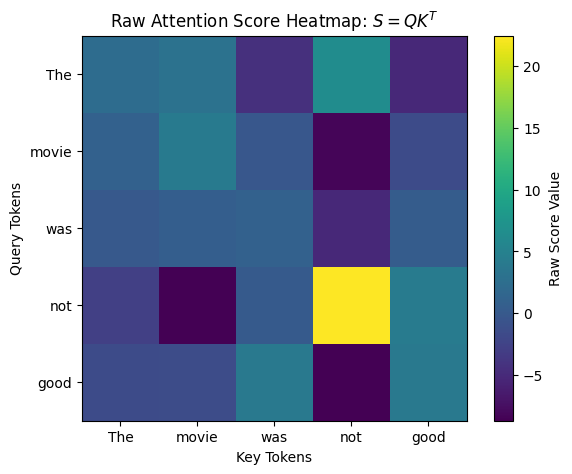

Shape of S: (5, 5)


In [ ]:
plt.figure(figsize=(7, 5))

plt.imshow(S, cmap="viridis")
plt.colorbar(label="Raw Score Value")

plt.xticks(range(len(tokens)), tokens)
plt.yticks(range(len(tokens)), tokens)

plt.xlabel("Key Tokens")
plt.ylabel("Query Tokens")
plt.title("Raw Attention Score Heatmap: $S = QK^T$")

plt.show()

print("Shape of S:", S.shape)

## Observation

The heatmap shows the complete raw interaction map:

$$
S = QK^\top
$$

---

### How to Read the Heatmap

For any row:

- Choose one query token
- Move across the row
- Compare how strongly it scores against all key tokens

---

### Example

The row for "good" shows:

> How strongly "good" attends to all tokens before normalization

---

### Important Warning

A brighter cell does not yet mean final attention.

At this stage, values are:

- Raw dot products
- Not scaled
- Not normalized

---

### Why This Matters

If raw scores become very large, then after softmax:

- One token may dominate
- Other tokens may receive near-zero attention
- Gradients can become unstable

This motivates scaling by:

$$
\sqrt{d_k}
$$

## Bridge to Next Section

We have now visualized raw attention scores.

But raw dot products can become large when the key/query dimension increases.

This creates a softmax sharpness problem.

To control this, scaled dot-product attention divides scores by:

$$
\sqrt{d_k}
$$

---

Next Section:

## Why Scaling by $\sqrt{d_k}$ Is Needed

## Why Scaling by $\sqrt{d_k}$ Is Needed

In self-attention, raw scores are computed using dot products:

$$
S = QK^\top
$$

Each score is:

$$
S_{ij} = q_i^\top k_j
$$

---

### Problem

When the dimension $d_k$ becomes large, the dot product can also become large in magnitude.

Large dot-product scores create a problem when passed into softmax.

---

### Softmax Problem

Softmax converts raw scores into probabilities.

But if one score is much larger than the others, softmax becomes very sharp.

That means:

- One token gets almost all attention
- Other tokens get almost zero attention
- Gradients become weak for most tokens

---

### Solution

To control the magnitude of dot products, we scale by:

$$
\sqrt{d_k}
$$

So instead of using:

$$
QK^\top
$$

we use:

$$
\frac{QK^\top}{\sqrt{d_k}}
$$

---

### Intuition

Scaling prevents attention from becoming too confident too early.

## Mathematical Reason for Scaling

Assume the components of query and key vectors are roughly independent random variables.

Let:

$$
q_i =
[q_{i1}, q_{i2}, \ldots, q_{id_k}]
$$

and:

$$
k_j =
[k_{j1}, k_{j2}, \ldots, k_{jd_k}]
$$

The raw dot product is:

$$
q_i^\top k_j
=
\sum_{\ell=1}^{d_k} q_{i\ell}k_{j\ell}
$$

---

### Variance Argument

If each product term has variance approximately $1$, then:

$$
\mathrm{Var}(q_i^\top k_j)
=
\mathrm{Var}
\left(
\sum_{\ell=1}^{d_k} q_{i\ell}k_{j\ell}
\right)
$$

Assuming independence:

$$
\mathrm{Var}(q_i^\top k_j)
=
\sum_{\ell=1}^{d_k}
\mathrm{Var}(q_{i\ell}k_{j\ell})
$$

So:

$$
\mathrm{Var}(q_i^\top k_j)
\approx d_k
$$

Therefore, the standard deviation grows like:

$$
\sqrt{d_k}
$$

---

### Scaling

To keep the variance approximately stable, divide by:

$$
\sqrt{d_k}
$$

Thus:

$$
S_{\text{scaled}}
=
\frac{QK^\top}{\sqrt{d_k}}
$$

---

### Final Insight

Without scaling:

$$
q_i^\top k_j
$$

can grow with dimension.

With scaling:

$$
\frac{q_i^\top k_j}{\sqrt{d_k}}
$$

has controlled magnitude.

Dimensions: [2, 4, 8, 16, 32, 64, 128]
Std of raw dot products: [np.float64(1.3797939792498009), np.float64(2.087396297289361), np.float64(2.937274339800914), np.float64(4.00457370678326), np.float64(5.324455456164642), np.float64(7.880150665012426), np.float64(11.018785791800498)]
Std of scaled dot products: [np.float64(0.9756616793679045), np.float64(1.0436981486446806), np.float64(1.0384833019392328), np.float64(1.001143426695815), np.float64(0.9412396397949326), np.float64(0.9850188331265533), np.float64(0.9739322692280141)]


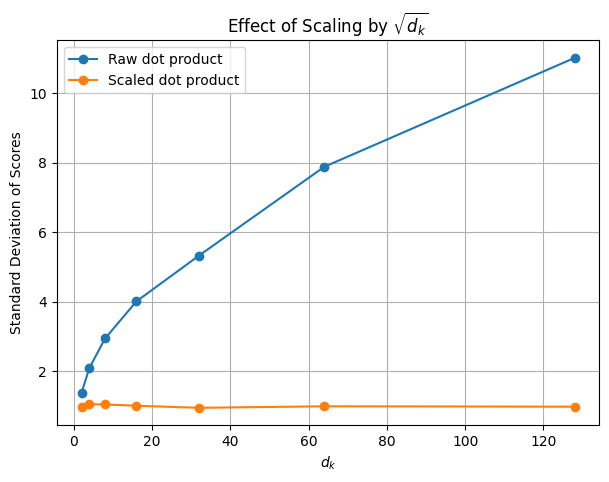

In [ ]:
# Demonstrate why dot products grow with dimension

dimensions = [2, 4, 8, 16, 32, 64, 128]
num_trials = 1000

average_raw_scores = []
average_scaled_scores = []

for dim in dimensions:
    raw_scores = []
    scaled_scores = []

    for _ in range(num_trials):
        q = np.random.randn(dim)
        k = np.random.randn(dim)

        raw_score = np.dot(q, k)
        scaled_score = raw_score / np.sqrt(dim)

        raw_scores.append(raw_score)
        scaled_scores.append(scaled_score)

    average_raw_scores.append(np.std(raw_scores))
    average_scaled_scores.append(np.std(scaled_scores))

print("Dimensions:", dimensions)
print("Std of raw dot products:", average_raw_scores)
print("Std of scaled dot products:", average_scaled_scores)

plt.figure(figsize=(7, 5))
plt.plot(dimensions, average_raw_scores, marker="o", label="Raw dot product")
plt.plot(dimensions, average_scaled_scores, marker="o", label="Scaled dot product")

plt.xlabel("$d_k$")
plt.ylabel("Standard Deviation of Scores")
plt.title("Effect of Scaling by $\\sqrt{d_k}$")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
S_scaled = S / np.sqrt(d_k)

print("Shape of raw score matrix S:", S.shape)
print("Shape of scaled score matrix S_scaled:", S_scaled.shape)

print("\nRaw Score Matrix S:\n", S)
print("\nScaled Score Matrix S_scaled:\n", S_scaled)

print("\nRaw score standard deviation:", np.std(S))
print("Scaled score standard deviation:", np.std(S_scaled))

Shape of raw score matrix S: (5, 5)
Shape of scaled score matrix S_scaled: (5, 5)

Raw Score Matrix S:
 [[ 2.25704878e+00  3.08875399e+00 -4.42092435e+00  6.43013789e+00
  -5.10473717e+00]
 [ 1.01013836e+00  4.08892911e+00 -2.86648828e-01 -8.34963965e+00
  -1.59918069e+00]
 [ 7.69157645e-03  6.25130830e-01  9.65545002e-01 -5.08823008e+00
   3.77974254e-01]
 [-2.83538480e+00 -8.72733375e+00  9.07905247e-02  2.24746107e+01
   4.20733697e+00]
 [-1.60496181e+00 -1.49274143e+00  3.85609109e+00 -8.66147015e+00
   3.91767145e+00]]

Scaled Score Matrix S_scaled:
 [[ 1.30310772e+00  1.78329295e+00 -2.55242186e+00  3.71244184e+00
  -2.94722138e+00]
 [ 5.83203657e-01  2.36074432e+00 -1.65496778e-01 -4.82066670e+00
  -9.23287402e-01]
 [ 4.44073374e-03  3.60919453e-01  5.57457667e-01 -2.93769100e+00
   2.18223538e-01]
 [-1.63701018e+00 -5.03872849e+00  5.24179339e-02  1.29757225e+01
   2.42910713e+00]
 [-9.26625136e-01 -8.61834666e-01  2.22631523e+00 -5.00070212e+00
   2.26186867e+00]]

Raw score s

## Observation

From the simulation, we observe:

- Raw dot-product score magnitude increases as $d_k$ increases
- Scaled dot-product scores remain more stable

---

### Why This Matters

If raw scores become too large, then softmax becomes overly confident.

That produces attention weights like:

$$
[0.001, 0.002, 0.990, 0.004, 0.003]
$$

This means one token dominates almost completely.

---

### With Scaling

After dividing by:

$$
\sqrt{d_k}
$$

the scores become less extreme.

Softmax then produces smoother attention distributions.

---

### Key Teaching Point

Scaling does not change the logic of attention.

It only stabilizes the magnitude of attention scores.

---

### Practical Meaning

Scaling helps training because:

- Attention does not collapse too early
- Gradients remain healthier
- Learning remains smoother

## Concept Check

1. Why can raw dot products become large when $d_k$ increases?

2. What happens when large scores are passed into softmax?

3. Why do we divide by $\sqrt{d_k}$ instead of $d_k$?

4. Does scaling change the shape of the score matrix?

5. What is the shape of $S_{\text{scaled}}$ in our example?

## Bridge to Next Section

We now know why scaled dot-product attention uses:

$$
\frac{QK^\top}{\sqrt{d_k}}
$$

But to fully feel the problem, we should inspect what softmax does to:

- Small scores
- Medium scores
- Large scores

---

Next Section:

## Softmax Sharpness Problem

## Softmax Sharpness Problem

Softmax converts a vector of raw scores into a probability distribution.

In attention, each row of the score matrix is passed through softmax.

---

### Recall

For a query token $i$, we have raw scores:

$$
S_{i,:}
=
[
S_{i1}, S_{i2}, \ldots, S_{in}
]
$$

Softmax converts this row into attention weights:

$$
A_{i,:}
=
[
A_{i1}, A_{i2}, \ldots, A_{in}
]
$$

---

### Problem

If raw scores are very large or very spread out, softmax becomes extremely sharp.

That means:

- One value becomes very close to $1$
- Most other values become very close to $0$

---

### Why This Is Dangerous

If one token dominates too early:

- The model may ignore useful context
- Learning becomes unstable
- Gradients for low-attention tokens become very small

---

### Key Idea

Scaling by $\sqrt{d_k}$ reduces score magnitude before softmax.

This produces smoother attention weights.

## Mathematics of Softmax Sharpness

For a score vector:

$$
s =
[s_1, s_2, \ldots, s_n]
$$

softmax is defined as:

$$
\mathrm{softmax}(s_j)
=
\frac{e^{s_j}}{\sum_{m=1}^{n} e^{s_m}}
$$

---

### Row-wise Attention

For each row $i$:

$$
A_{ij}
=
\frac{
\exp(S_{ij})
}{
\sum_{m=1}^{n} \exp(S_{im})
}
$$

---

### With Scaling

Instead of applying softmax to raw scores:

$$
S_{ij}
$$

we apply it to:

$$
\frac{S_{ij}}{\sqrt{d_k}}
$$

So:

$$
A_{ij}
=
\frac{
\exp \left( \frac{S_{ij}}{\sqrt{d_k}} \right)
}{
\sum_{m=1}^{n}
\exp \left( \frac{S_{im}}{\sqrt{d_k}} \right)
}
$$

---

### Important Property

For every row:

$$
\sum_{j=1}^{n} A_{ij} = 1
$$

and:

$$
0 \leq A_{ij} \leq 1
$$

So each row becomes a probability distribution.

In [ ]:
# Compare softmax behavior for different score magnitudes

small_scores = np.array([1.0, 1.2, 0.8, 1.1, 0.9])
medium_scores = np.array([2.0, 4.0, 1.0, 3.0, 0.5])
large_scores = np.array([10.0, 20.0, 5.0, 15.0, 2.0])

small_softmax = softmax(small_scores)
medium_softmax = softmax(medium_scores)
large_softmax = softmax(large_scores)

print("Small scores:", small_scores)
print("Softmax(small scores):", small_softmax)
print("Sum:", np.sum(small_softmax))

print("\nMedium scores:", medium_scores)
print("Softmax(medium scores):", medium_softmax)
print("Sum:", np.sum(medium_softmax))

print("\nLarge scores:", large_scores)
print("Softmax(large scores):", large_softmax)
print("Sum:", np.sum(large_softmax))

Small scores: [1.  1.2 0.8 1.1 0.9]
Softmax(small scores): [0.19801424 0.24185514 0.16212035 0.21883958 0.17917069]
Sum: 1.0

Medium scores: [2.  4.  1.  3.  0.5]
Softmax(medium scores): [0.08548216 0.63163247 0.03144713 0.2323646  0.01907365]
Sum: 1.0

Large scores: [10. 20.  5. 15.  2.]
Softmax(large scores): [4.50940269e-05 9.93262040e-01 3.03841163e-07 6.69254698e-03
 1.51273608e-08]
Sum: 1.0000000000000002


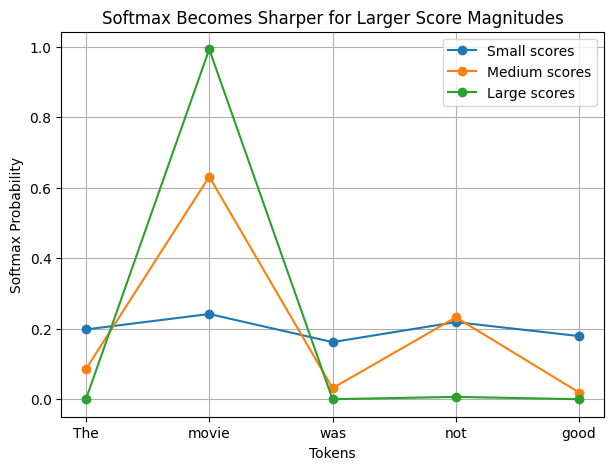

In [ ]:
labels = ["The", "movie", "was", "not", "good"]

x = np.arange(len(labels))

plt.figure(figsize=(7, 5))
plt.plot(x, small_softmax, marker="o", label="Small scores")
plt.plot(x, medium_softmax, marker="o", label="Medium scores")
plt.plot(x, large_softmax, marker="o", label="Large scores")

plt.xticks(x, labels)
plt.xlabel("Tokens")
plt.ylabel("Softmax Probability")
plt.title("Softmax Becomes Sharper for Larger Score Magnitudes")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Compare attention distribution for token "good"
good_index = tokens.index("good")

raw_good_scores = S[good_index]
scaled_good_scores = S_scaled[good_index]

raw_good_attention = softmax(raw_good_scores)
scaled_good_attention = softmax(scaled_good_scores)

print("Token:", tokens[good_index])

print("\nRaw scores for 'good':")
print(raw_good_scores)

print("\nScaled scores for 'good':")
print(scaled_good_scores)

print("\nSoftmax on raw scores:")
print(raw_good_attention)
print("Sum:", np.sum(raw_good_attention))

print("\nSoftmax on scaled scores:")
print(scaled_good_attention)
print("Sum:", np.sum(scaled_good_attention))

Token: good

Raw scores for 'good':
[-1.60496181 -1.49274143  3.85609109 -8.66147015  3.91767145]

Scaled scores for 'good':
[-0.92662514 -0.86183467  2.22631523 -5.00070212  2.26186867]

Softmax on raw scores:
[2.05019715e-03 2.29367732e-03 4.82503833e-01 1.76682279e-06
 5.13150525e-01]
Sum: 1.0

Softmax on scaled scores:
[2.01043022e-02 2.14499926e-02 4.70536813e-01 3.41932081e-04
 4.87566960e-01]
Sum: 0.9999999999999998


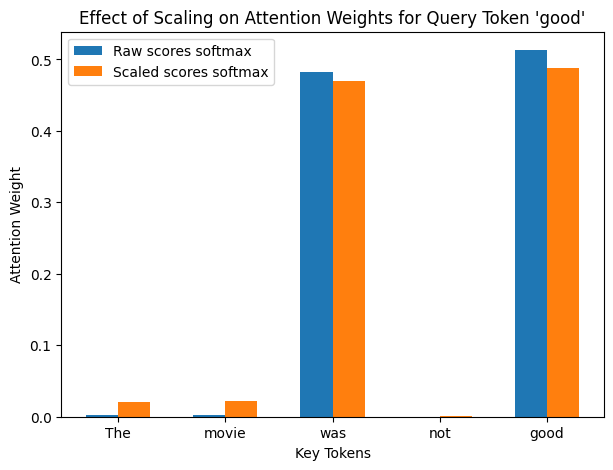

In [ ]:
x = np.arange(len(tokens))

plt.figure(figsize=(7, 5))

plt.bar(x - 0.15, raw_good_attention, width=0.3, label="Raw scores softmax")
plt.bar(x + 0.15, scaled_good_attention, width=0.3, label="Scaled scores softmax")

plt.xticks(x, tokens)
plt.xlabel("Key Tokens")
plt.ylabel("Attention Weight")
plt.title("Effect of Scaling on Attention Weights for Query Token 'good'")
plt.legend()
plt.show()

## Observation

Softmax behaves very differently depending on the magnitude of input scores.

---

### Small Scores

When scores are close together:

$$
[1.0, 1.2, 0.8, 1.1, 0.9]
$$

softmax gives a smoother distribution.

No single token dominates completely.

---

### Large Scores

When scores are large and spread out:

$$
[10, 20, 5, 15, 2]
$$

softmax becomes almost one-hot.

One value receives almost all probability.

---

### Attention Interpretation

In attention, this means:

> The model may attend almost entirely to one token and ignore the rest.

---

### Why Scaling Helps

Scaling reduces the magnitude of raw scores:

$$
S_{\text{scaled}}
=
\frac{S}{\sqrt{d_k}}
$$

This makes softmax less extreme.

---

### Important Teaching Point

Softmax is not only about ranking scores.

It is also highly sensitive to score magnitude.

## Concept Check

1. What does softmax do to a vector of scores?

2. Why does softmax become sharp when scores are large?

3. What does it mean when attention becomes almost one-hot?

4. Why is one-hot attention too early in training problematic?

5. How does scaling by $\sqrt{d_k}$ help?

## Bridge to Next Section

We now understand both problems:

1. Raw dot products can grow with $d_k$
2. Softmax becomes too sharp for large scores

This motivates the final scaled dot-product attention formula:

$$
\mathrm{Attention}(Q,K,V)
=
\mathrm{softmax}
\left(
\frac{QK^\top}{\sqrt{d_k}}
\right)V
$$

---

Next Section:

## Scaled Dot-Product Attention Formula

## Scaled Dot-Product Attention Formula

We are now ready to combine the full self-attention mechanism.

So far, we computed:

1. Query matrix $Q$
2. Key matrix $K$
3. Value matrix $V$
4. Raw score matrix $S = QK^\top$
5. Scaled score matrix:

$$
S_{\text{scaled}} = \frac{QK^\top}{\sqrt{d_k}}
$$

---

### Final Idea

Attention works in two stages:

1. Compute how strongly tokens attend to each other
2. Use those attention weights to combine information from value vectors

---

### Full Formula

The scaled dot-product attention formula is:

$$
\mathrm{Attention}(Q,K,V)
=
\mathrm{softmax}
\left(
\frac{QK^\top}{\sqrt{d_k}}
\right)V
$$

---

### Interpretation

- $QK^\top$ computes raw similarity scores
- $\sqrt{d_k}$ stabilizes score magnitude
- Softmax converts scores into attention weights
- Multiplication by $V$ creates contextual token representations

## Mathematical Derivation

We start with:

$$
Q \in \mathbb{R}^{n \times d_k}
$$

$$
K \in \mathbb{R}^{n \times d_k}
$$

$$
V \in \mathbb{R}^{n \times d_k}
$$

---

### Step 1: Raw Scores

$$
S = QK^\top
$$

Shape:

$$
(n \times d_k)(d_k \times n) = n \times n
$$

So:

$$
S \in \mathbb{R}^{n \times n}
$$

---

### Step 2: Scaled Scores

$$
S_{\text{scaled}} = \frac{S}{\sqrt{d_k}}
$$

or:

$$
S_{\text{scaled}} = \frac{QK^\top}{\sqrt{d_k}}
$$

Shape remains:

$$
S_{\text{scaled}} \in \mathbb{R}^{n \times n}
$$

---

### Step 3: Attention Weights

Apply row-wise softmax:

$$
A =
\mathrm{softmax}
\left(
\frac{QK^\top}{\sqrt{d_k}}
\right)
$$

Shape:

$$
A \in \mathbb{R}^{n \times n}
$$

Each row satisfies:

$$
\sum_{j=1}^{n} A_{ij} = 1
$$

---

### Step 4: Contextual Output

Finally:

$$
Z = AV
$$

Shape:

$$
(n \times n)(n \times d_k) = n \times d_k
$$

So:

$$
Z \in \mathbb{R}^{n \times d_k}
$$

---

### Complete Formula

$$
Z =
\mathrm{softmax}
\left(
\frac{QK^\top}{\sqrt{d_k}}
\right)V
$$

---

### Element-wise View

For token $i$:

$$
z_i =
\sum_{j=1}^{n} A_{ij}v_j
$$

So each updated token representation is a weighted combination of all value vectors.

In [ ]:
# Step 1: Raw scores
S = Q @ K.T

# Step 2: Scale scores
S_scaled = S / np.sqrt(d_k)

# Step 3: Row-wise softmax to get attention weights
A = row_softmax(S_scaled)

# Step 4: Weighted combination of value vectors
Z = A @ V

print("Shape of Q:", Q.shape)
print("Shape of K:", K.shape)
print("Shape of V:", V.shape)

print("\nShape of raw score matrix S = QK^T:", S.shape)
print("Shape of scaled score matrix:", S_scaled.shape)
print("Shape of attention weight matrix A:", A.shape)
print("Shape of contextual output Z:", Z.shape)

print("\nAttention Weight Matrix A:\n", A)
print("\nContextual Output Z:\n", Z)

Shape of Q: (5, 3)
Shape of K: (5, 3)
Shape of V: (5, 3)

Shape of raw score matrix S = QK^T: (5, 5)
Shape of scaled score matrix: (5, 5)
Shape of attention weight matrix A: (5, 5)
Shape of contextual output Z: (5, 3)

Attention Weight Matrix A:
 [[7.25776547e-02 1.17312618e-01 1.53591686e-03 8.07538887e-01
  1.03492400e-03]
 [1.31329123e-01 7.76849959e-01 6.21161569e-02 5.90867320e-04
  2.91138937e-02]
 [1.83221056e-01 2.61693011e-01 3.18527979e-01 9.66548841e-03
  2.26892466e-01]
 [4.50565712e-07 1.50110354e-08 2.44043613e-06 9.99970812e-01
  2.62815182e-05]
 [2.01043022e-02 2.14499926e-02 4.70536813e-01 3.41932081e-04
  4.87566960e-01]]

Contextual Output Z:
 [[-2.50377197e+00 -5.04967045e-01  3.24360549e+00]
 [ 9.42526565e-01  3.36494421e-01  1.85808013e-01]
 [ 7.16260242e-01  2.41347400e-01 -1.89277073e-01]
 [-3.28315813e+00 -7.47080420e-01  3.90558397e+00]
 [ 7.46486816e-01 -2.58404670e-03 -7.64146038e-01]]


In [ ]:
row_sums = np.sum(A, axis=1)

print("Attention matrix shape:", A.shape)
print("Row sums of attention matrix:")

for token, row_sum in zip(tokens, row_sums):
    print(f"{token}: {row_sum:.6f}")

Attention matrix shape: (5, 5)
Row sums of attention matrix:
The: 1.000000
movie: 1.000000
was: 1.000000
not: 1.000000
good: 1.000000


## Observation

We computed the full scaled dot-product attention output:

$$
Z =
\mathrm{softmax}
\left(
\frac{QK^\top}{\sqrt{d_k}}
\right)V
$$

---

### Shape Flow

The complete shape flow is:

$$
X \in \mathbb{R}^{5 \times 4}
$$

$$
Q,K,V \in \mathbb{R}^{5 \times 3}
$$

$$
S = QK^\top \in \mathbb{R}^{5 \times 5}
$$

$$
A \in \mathbb{R}^{5 \times 5}
$$

$$
Z = AV \in \mathbb{R}^{5 \times 3}
$$

---

### Meaning of $A$

The matrix $A$ tells us:

> How much each token attends to every other token

Each row of $A$ is a probability distribution.

---

### Meaning of $Z$

The matrix $Z$ contains updated token representations.

Each row $z_i$ is no longer isolated.

Instead:

$$
z_i =
\sum_{j=1}^{n} A_{ij}v_j
$$

So $z_i$ contains information from all tokens, weighted by attention.

---

### Key Insight

The original embedding $x_i$ represents a token independently.

The updated representation $z_i$ represents a token **contextually**.

## Concept Check

1. Write the full scaled dot-product attention formula.

2. What is the shape of $A$ in our example?

3. Why does each row of $A$ sum to $1$?

4. What does $Z = AV$ represent?

5. Why is $z_i$ called a contextual token representation?

## Bridge to Next Section

We have now implemented the full scaled dot-product attention formula:

$$
Z =
\mathrm{softmax}
\left(
\frac{QK^\top}{\sqrt{d_k}}
\right)V
$$

But we should examine the attention matrix $A$ more carefully.

The next question is:

> What exactly does the attention weight matrix tell us?

---

Next Section:

## Attention Weight Matrix

## Attention Weight Matrix

In the previous section, we computed:

$$
A =
\mathrm{softmax}
\left(
\frac{QK^\top}{\sqrt{d_k}}
\right)
$$

This matrix is called the **attention weight matrix**.

---

### What Does $A$ Represent?

The matrix $A$ tells us:

> How much each token attends to every other token.

---

### Row-wise Meaning

Each row of $A$ corresponds to one query token.

For example, the row for "good" tells us:

> When updating the representation of "good", how much information should come from each token?

---

### Column-wise Meaning

Each column corresponds to a key/value token.

For example, the column for "not" tells us:

> How much different tokens are attending to "not".

---

### Important Property

Each row of $A$ is a probability distribution.

So every row sums to:

$$
1
$$

This makes attention interpretable as a weighted averaging mechanism.

## Mathematical Structure of Attention Matrix

The attention matrix is:

$$
A =
\mathrm{softmax}
\left(
\frac{QK^\top}{\sqrt{d_k}}
\right)
$$

where softmax is applied row-wise.

---

### Shape

Since:

$$
QK^\top \in \mathbb{R}^{n \times n}
$$

therefore:

$$
A \in \mathbb{R}^{n \times n}
$$

---

### Element-wise Form

Each attention weight is:

$$
A_{ij}
=
\frac{
\exp
\left(
\frac{q_i^\top k_j}{\sqrt{d_k}}
\right)
}{
\sum_{m=1}^{n}
\exp
\left(
\frac{q_i^\top k_m}{\sqrt{d_k}}
\right)
}
$$

---

### Row-wise Probability Constraint

For each query token $i$:

$$
\sum_{j=1}^{n} A_{ij} = 1
$$

and:

$$
0 \leq A_{ij} \leq 1
$$

---

### Row Vector Interpretation

The $i$-th row is:

$$
A_{i,:}
=
[
A_{i1}, A_{i2}, \ldots, A_{in}
]
$$

This row decides how much each value vector contributes to the updated representation of token $i$.

---

### For Token "good"

$$
A_{\text{good},:}
=
[
A_{\text{good},\text{The}},
A_{\text{good},\text{movie}},
A_{\text{good},\text{was}},
A_{\text{good},\text{not}},
A_{\text{good},\text{good}}
]
$$

## Observation

The attention matrix has shape:

$$
A \in \mathbb{R}^{5 \times 5}
$$

---

### Meaning of Each Row

Each row tells us how one token distributes attention across all tokens.

For example:

$$
A_{\text{good},:}
$$

tells us how the token "good" attends to:

- "The"
- "movie"
- "was"
- "not"
- "good"

---

### Probability Interpretation

Each row sums to:

$$
1
$$

So each row can be interpreted as a probability distribution over tokens.

---

### Key Teaching Insight

Attention does not simply select one token.

It usually creates a **soft mixture** of information from multiple tokens.

---

### Important Point

The attention weights alone do not yet give the final output.

They only tell us:

> How much value information should be borrowed from each token.

The final contextual representation comes from:

$$
Z = AV
$$

## Bridge to Next Section

We now understand the attention weight matrix:

$$
A =
\mathrm{softmax}
\left(
\frac{QK^\top}{\sqrt{d_k}}
\right)
$$

But attention weights are only half of the story.

The real updated token representation is produced by:

$$
Z = AV
$$

This means each token becomes a weighted mixture of value vectors.

---

Next Section:

## Contextual Token Representation $Z = AV$

## Contextual Token Representation $Z = AV$

So far, we computed the attention weight matrix:

$$
A =
\mathrm{softmax}
\left(
\frac{QK^\top}{\sqrt{d_k}}
\right)
$$

The matrix $A$ only tells us **how much attention** each token gives to every other token.

But the final goal is not just to compute attention weights.

The final goal is to create **updated token representations**.

---

### Key Idea

Each token representation is updated by taking a weighted combination of value vectors.

This is done using:

$$
Z = AV
$$

---

### Meaning

For every token $i$:

- Row $A_{i,:}$ tells how much token $i$ attends to all tokens
- Matrix $V$ contains the information available from all tokens
- Multiplication $A_{i,:}V$ gives the updated representation of token $i$

---

### Important Interpretation

The original token embedding only represents the token itself.

The updated vector $z_i$ represents the token **in context**.

For example:

> The updated representation of "good" can now include information from "not".

## Mathematical Formulation

We have:

$$
A \in \mathbb{R}^{n \times n}
$$

and:

$$
V \in \mathbb{R}^{n \times d_k}
$$

The contextual output is:

$$
Z = AV
$$

---

### Shape Derivation

$$
A V
=
(n \times n)(n \times d_k)
$$

Therefore:

$$
Z \in \mathbb{R}^{n \times d_k}
$$

---

### In Our Example

Since:

$$
n = 5
$$

and:

$$
d_k = 3
$$

we get:

$$
A \in \mathbb{R}^{5 \times 5}
$$

$$
V \in \mathbb{R}^{5 \times 3}
$$

$$
Z \in \mathbb{R}^{5 \times 3}
$$

---

### Row-wise Formula

For token $i$:

$$
z_i =
\sum_{j=1}^{n} A_{ij} v_j
$$

---

### Expanded Form for Token "good"

$$
z_{\text{good}}
=
A_{\text{good},\text{The}}v_{\text{The}}
+
A_{\text{good},\text{movie}}v_{\text{movie}}
+
A_{\text{good},\text{was}}v_{\text{was}}
+
A_{\text{good},\text{not}}v_{\text{not}}
+
A_{\text{good},\text{good}}v_{\text{good}}
$$

---

### Interpretation

Each $z_i$ is a weighted mixture of all value vectors:

$$
z_i =
A_{i1}v_1
+
A_{i2}v_2
+
\cdots
+
A_{in}v_n
$$

So every output token representation can carry information from the full sequence.

In [ ]:
# Compute contextual token representations
Z = A @ V

print("Shape of A:", A.shape)
print("Shape of V:", V.shape)
print("Shape of Z:", Z.shape)

print("\nAttention matrix A:\n", A)
print("\nValue matrix V:\n", V)
print("\nContextual representation matrix Z:\n", Z)

Shape of A: (5, 5)
Shape of V: (5, 3)
Shape of Z: (5, 3)

Attention matrix A:
 [[7.25776547e-02 1.17312618e-01 1.53591686e-03 8.07538887e-01
  1.03492400e-03]
 [1.31329123e-01 7.76849959e-01 6.21161569e-02 5.90867320e-04
  2.91138937e-02]
 [1.83221056e-01 2.61693011e-01 3.18527979e-01 9.66548841e-03
  2.26892466e-01]
 [4.50565712e-07 1.50110354e-08 2.44043613e-06 9.99970812e-01
  2.62815182e-05]
 [2.01043022e-02 2.14499926e-02 4.70536813e-01 3.41932081e-04
  4.87566960e-01]]

Value matrix V:
 [[ 0.26094166  0.91576273  0.99489252]
 [ 1.07990872  0.27119818  0.16634579]
 [ 0.83261839  0.22266876 -0.86032427]
 [-3.28327378 -0.74709611  3.90572033]
 [ 0.67154219 -0.26935871 -0.78807027]]

Contextual representation matrix Z:
 [[-2.50377197e+00 -5.04967045e-01  3.24360549e+00]
 [ 9.42526565e-01  3.36494421e-01  1.85808013e-01]
 [ 7.16260242e-01  2.41347400e-01 -1.89277073e-01]
 [-3.28315813e+00 -7.47080420e-01  3.90558397e+00]
 [ 7.46486816e-01 -2.58404670e-03 -7.64146038e-01]]


In [ ]:
query_token = "good"
query_index = tokens.index(query_token)

z_good = Z[query_index]

print("Token:", query_token)
print("Shape of z_good:", z_good.shape)
print("\nz_good:\n", z_good)

print("\nAttention weights used for updating 'good':")

for token, weight in zip(tokens, A[query_index]):
    print(f"Weight from {token}: {weight:.4f}")

Token: good
Shape of z_good: (3,)

z_good:
 [ 0.74648682 -0.00258405 -0.76414604]

Attention weights used for updating 'good':
Weight from The: 0.0201
Weight from movie: 0.0214
Weight from was: 0.4705
Weight from not: 0.0003
Weight from good: 0.4876


In [ ]:
# Manually compute z_good using weighted sum of value vectors

manual_z_good = np.zeros(d_k)

for j, token in enumerate(tokens):
    contribution = A[query_index, j] * V[j]
    manual_z_good += contribution

    print(f"Contribution from {token}:")
    print(contribution)
    print()

print("Manual z_good:")
print(manual_z_good)

print("\nMatrix multiplication z_good:")
print(z_good)

print("\nAre both equal?", np.allclose(manual_z_good, z_good))

Contribution from The:
[0.00524605 0.01841077 0.02000162]

Contribution from movie:
[0.02316403 0.0058172  0.00356812]

Contribution from was:
[ 0.3917776   0.10477385 -0.40481424]

Contribution from not:
[-0.00112266 -0.00025546  0.00133549]

Contribution from good:
[ 0.32742178 -0.13133041 -0.38423703]

Manual z_good:
[ 0.74648682 -0.00258405 -0.76414604]

Matrix multiplication z_good:
[ 0.74648682 -0.00258405 -0.76414604]

Are both equal? True


## Observation

We computed:

$$
Z = AV
$$

with shape:

$$
Z \in \mathbb{R}^{5 \times 3}
$$

---

### Meaning of $Z$

Each row of $Z$ is an updated token representation.

So:

$$
z_i
$$

is no longer just the original representation of token $i$.

It is a context-aware representation built from all value vectors.

---

### For Token "good"

The updated representation:

$$
z_{\text{good}}
$$

is formed using:

$$
A_{\text{good},\text{The}}v_{\text{The}}
+
A_{\text{good},\text{movie}}v_{\text{movie}}
+
A_{\text{good},\text{was}}v_{\text{was}}
+
A_{\text{good},\text{not}}v_{\text{not}}
+
A_{\text{good},\text{good}}v_{\text{good}}
$$

---

### Key Teaching Point

Attention does not copy one token.

It creates a weighted average of information from multiple tokens.

---

### Why This Matters

Now the representation of "good" can include contextual information from "not".

This is how self-attention helps capture relationships inside a sentence.

---

### Important Limitation

Because our vectors are random and untrained, the attention weights may not reflect true language meaning.

The purpose here is to understand the mechanism and shapes.

## Concept Check

1. What is the formula for the contextual output matrix?

2. What is the shape of $Z$ in our example?

3. What does each row $z_i$ represent?

4. Why is $z_i$ called contextual?

5. What is the role of $V$ in computing $Z$?

6. Why should we not overinterpret the attention weights in this toy example?

## Bridge to Next Section

We have now visualized the final attention matrix:

$$
A
$$

and interpreted it as a token-to-token information flow map.

But one final comparison is still important.

We started with original embeddings:

$$
X
$$

and ended with updated contextual representations:

$$
Z
$$

Next, we compare:

- Original embedding of a token
- Attention-updated representation of the same token

This will help us clearly see what self-attention changes.

---

Next Section:

## Original Embedding vs Attention-Updated Embedding

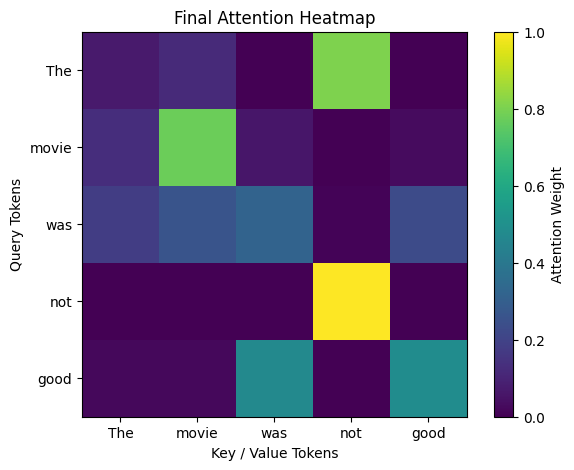

Shape of attention matrix A: (5, 5)


In [ ]:
plt.figure(figsize=(7, 5))

plt.imshow(A, cmap="viridis", vmin=0, vmax=1)
plt.colorbar(label="Attention Weight")

plt.xticks(range(len(tokens)), tokens)
plt.yticks(range(len(tokens)), tokens)

plt.xlabel("Key / Value Tokens")
plt.ylabel("Query Tokens")
plt.title("Final Attention Heatmap")

plt.show()

print("Shape of attention matrix A:", A.shape)

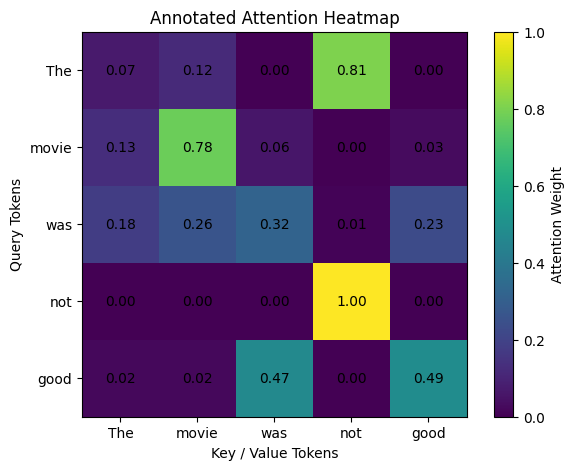

In [ ]:
plt.figure(figsize=(7, 5))

plt.imshow(A, cmap="viridis", vmin=0, vmax=1)
plt.colorbar(label="Attention Weight")

plt.xticks(range(len(tokens)), tokens)
plt.yticks(range(len(tokens)), tokens)

plt.xlabel("Key / Value Tokens")
plt.ylabel("Query Tokens")
plt.title("Annotated Attention Heatmap")

# Add numerical values inside each cell
for i in range(len(tokens)):
    for j in range(len(tokens)):
        plt.text(j, i, f"{A[i, j]:.2f}", ha="center", va="center")

plt.show()

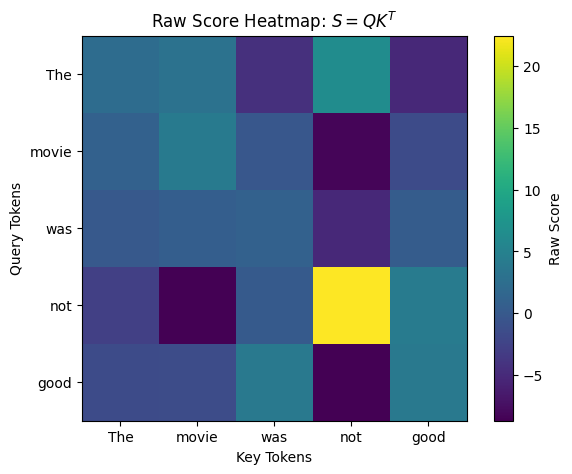

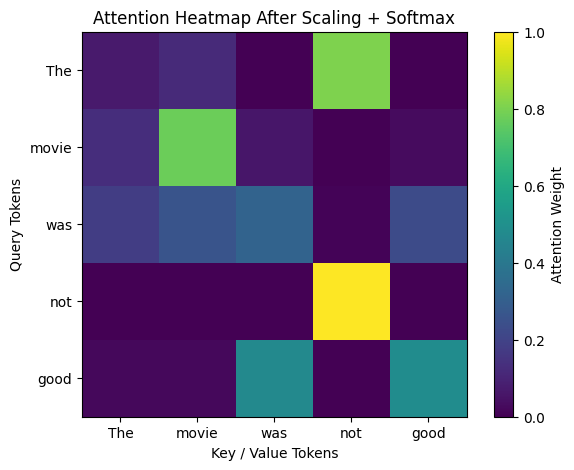

Raw score matrix shape: (5, 5)
Attention matrix shape: (5, 5)


In [ ]:
# Raw score heatmap
plt.figure(figsize=(7, 5))

plt.imshow(S, cmap="viridis")
plt.colorbar(label="Raw Score")

plt.xticks(range(len(tokens)), tokens)
plt.yticks(range(len(tokens)), tokens)

plt.xlabel("Key Tokens")
plt.ylabel("Query Tokens")
plt.title("Raw Score Heatmap: $S = QK^T$")

plt.show()


# Final attention heatmap
plt.figure(figsize=(7, 5))

plt.imshow(A, cmap="viridis", vmin=0, vmax=1)
plt.colorbar(label="Attention Weight")

plt.xticks(range(len(tokens)), tokens)
plt.yticks(range(len(tokens)), tokens)

plt.xlabel("Key / Value Tokens")
plt.ylabel("Query Tokens")
plt.title("Attention Heatmap After Scaling + Softmax")

plt.show()

print("Raw score matrix shape:", S.shape)
print("Attention matrix shape:", A.shape)

In [ ]:
print("Most attended token for each query token:\n")

for i, query_token in enumerate(tokens):
    max_index = np.argmax(A[i])
    max_token = tokens[max_index]
    max_weight = A[i, max_index]

    print(f"{query_token} attends most to {max_token} with weight {max_weight:.4f}")

Most attended token for each query token:

The attends most to not with weight 0.8075
movie attends most to movie with weight 0.7768
was attends most to was with weight 0.3185
not attends most to not with weight 1.0000
good attends most to good with weight 0.4876


## Concept Check

1. What does a row in the attention heatmap represent?

2. What does a column in the attention heatmap represent?

3. Why is the attention heatmap easier to interpret than the raw score heatmap?

4. Why does every row of the attention heatmap sum to $1$?

5. If "good" does not attend strongly to "not" in this toy example, should we conclude self-attention failed?

6. What is the main purpose of visualizing $A$?

## Original Embedding vs Attention-Updated Embedding

We started with the input embedding matrix:

$$
X \in \mathbb{R}^{n \times d_{model}}
$$

Each row of $X$ represents a token before self-attention.

---

### Original Embedding

The original embedding of a token is mostly a standalone representation.

For example:

$$
x_{\text{good}}
$$

represents the token "good" before it has interacted with other tokens.

---

### Attention-Updated Representation

After self-attention, we obtain:

$$
Z = AV
$$

Each row of $Z$ is an updated representation.

For example:

$$
z_{\text{good}}
$$

represents "good" after it has collected information from other tokens.

---

### Key Difference

Original embedding:

> Token representation before contextual interaction

Attention-updated embedding:

> Token representation after contextual interaction

---

### Important Note

In our toy setup:

$$
x_{\text{good}} \in \mathbb{R}^{4}
$$

while:

$$
z_{\text{good}} \in \mathbb{R}^{3}
$$

So we cannot directly subtract them dimension-wise in this example.

Instead, we compare their values visually and conceptually.

## Mathematical Comparison

Original token embedding:

$$
x_i \in \mathbb{R}^{d_{model}}
$$

Attention-updated representation:

$$
z_i \in \mathbb{R}^{d_k}
$$

---

### In Our Example

Since:

$$
d_{model} = 4
$$

and:

$$
d_k = 3
$$

we have:

$$
x_i \in \mathbb{R}^{4}
$$

and:

$$
z_i \in \mathbb{R}^{3}
$$

---

### Transformation Flow

$$
x_i
\rightarrow
q_i, k_i, v_i
\rightarrow
A_{i,:}
\rightarrow
z_i
$$

---

### Attention-Updated Representation

For token $i$:

$$
z_i =
\sum_{j=1}^{n} A_{ij}v_j
$$

---

### For Token "good"

$$
z_{\text{good}}
=
\sum_{j=1}^{5}
A_{\text{good},j}v_j
$$

Expanded:

$$
z_{\text{good}}
=
A_{\text{good},\text{The}}v_{\text{The}}
+
A_{\text{good},\text{movie}}v_{\text{movie}}
+
A_{\text{good},\text{was}}v_{\text{was}}
+
A_{\text{good},\text{not}}v_{\text{not}}
+
A_{\text{good},\text{good}}v_{\text{good}}
$$

---

### Meaning

The vector $x_{\text{good}}$ comes directly from the embedding matrix.

The vector $z_{\text{good}}$ is constructed using information from the entire sentence.

Token: good

Original embedding x_good:
[-1.01283112  0.31424733 -0.90802408 -1.4123037 ]
Shape of x_good: (4,)

Attention-updated representation z_good:
[ 0.74648682 -0.00258405 -0.76414604]
Shape of z_good: (3,)


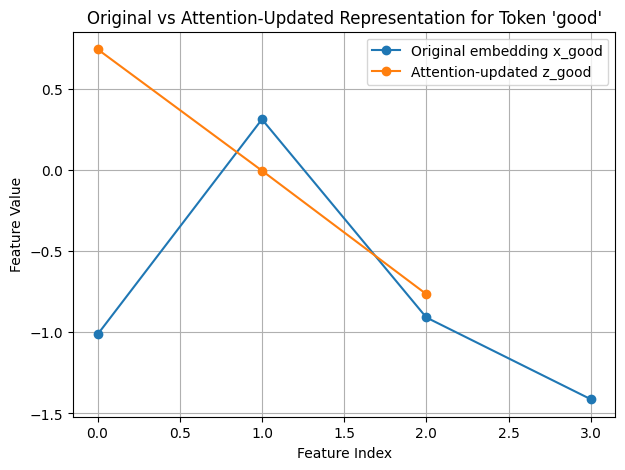

In [ ]:
token = "good"
idx = tokens.index(token)

x_good = X[idx]
z_good = Z[idx]

print("Token:", token)

print("\nOriginal embedding x_good:")
print(x_good)
print("Shape of x_good:", x_good.shape)

print("\nAttention-updated representation z_good:")
print(z_good)
print("Shape of z_good:", z_good.shape)
plt.figure(figsize=(7, 5))

plt.plot(range(len(x_good)), x_good, marker="o", label="Original embedding x_good")
plt.plot(range(len(z_good)), z_good, marker="o", label="Attention-updated z_good")

plt.xlabel("Feature Index")
plt.ylabel("Feature Value")
plt.title("Original vs Attention-Updated Representation for Token 'good'")
plt.legend()
plt.grid(True)

plt.show()

## Observation

For token "good", we compared:

$$
x_{\text{good}}
$$

and:

$$
z_{\text{good}}
$$

---

### Important Shape Point

In our example:

$$
x_{\text{good}} \in \mathbb{R}^{4}
$$

but:

$$
z_{\text{good}} \in \mathbb{R}^{3}
$$

So their dimensions are different because:

$$
d_{model} \neq d_k
$$

---

### Better Technical Comparison

A more direct comparison is between:

$$
v_{\text{good}}
$$

and:

$$
z_{\text{good}}
$$

because both are in:

$$
\mathbb{R}^{3}
$$

---

### What Changed?

The value vector:

$$
v_{\text{good}}
$$

comes only from the token "good".

But:

$$
z_{\text{good}}
$$

is formed from a weighted combination of all value vectors:

$$
z_{\text{good}}
=
\sum_{j=1}^{5}
A_{\text{good},j}v_j
$$

---

### Core Insight

Self-attention changes token representation from:

> Isolated token vector

to:

> Context-aware token vector

---

### Important Classroom Warning

Because the vectors are random, the direction of change does not have semantic meaning.

What matters is the mechanism:

$$
Z = AV
$$

## Concept Check

1. What is the difference between $x_i$ and $z_i$?

2. Why can we not directly subtract $x_{\text{good}}$ and $z_{\text{good}}$ in this example?

3. Why is comparing $v_{\text{good}}$ with $z_{\text{good}}$ more technically valid?

4. What does $z_{\text{good}}$ contain that $v_{\text{good}}$ alone does not?

5. Why should we not attach semantic meaning to the direction of change in this toy example?

## Bridge to Next Section

We have now completed the main self-attention pipeline:

$$
X
\rightarrow
Q,K,V
\rightarrow
QK^\top
\rightarrow
\frac{QK^\top}{\sqrt{d_k}}
\rightarrow
A
\rightarrow
Z
$$

We have also compared:

- Original token representation
- Value vector
- Attention-updated contextual representation

The next section summarizes the complete lecture and prepares the bridge toward multi-head attention.

---

Next Section:

## Summary and Bridge to Multi-Head Attention

## Summary and Bridge to Multi-Head Attention

In this lecture, we moved from encoder–decoder attention to self-attention.

The major conceptual shift was:

> In self-attention, every token attends to every other token in the same sequence.

---

### Complete Self-Attention Flow

We started with the input matrix:

$$
X \in \mathbb{R}^{n \times d_{model}}
$$

Then projected it into:

$$
Q = XW_Q
$$

$$
K = XW_K
$$

$$
V = XW_V
$$

Then computed attention scores:

$$
S = QK^\top
$$

Then scaled the scores:

$$
S_{\text{scaled}} = \frac{QK^\top}{\sqrt{d_k}}
$$

Then applied row-wise softmax:

$$
A =
\mathrm{softmax}
\left(
\frac{QK^\top}{\sqrt{d_k}}
\right)
$$

Finally, we computed contextual token representations:

$$
Z = AV
$$

---

### Key Interpretation

The final output:

$$
Z
$$

contains contextual token representations.

Each token representation is updated using a weighted combination of value vectors from the full sequence.

---

### Why This Matters

Self-attention allows a token like "good" to incorporate context from a token like "not".

This is the core mechanism that allows Transformer-based models to represent contextual meaning.

## Complete Mathematical Summary

Let:

$$
X \in \mathbb{R}^{n \times d_{model}}
$$

Projection matrices:

$$
W_Q, W_K, W_V \in \mathbb{R}^{d_{model} \times d_k}
$$

Projected matrices:

$$
Q,K,V \in \mathbb{R}^{n \times d_k}
$$

---

### Raw Scores

$$
S = QK^\top
$$

$$
S \in \mathbb{R}^{n \times n}
$$

Element-wise:

$$
S_{ij} = q_i^\top k_j
$$

---

### Scaled Scores

$$
S_{\text{scaled}}
=
\frac{QK^\top}{\sqrt{d_k}}
$$

---

### Attention Matrix

$$
A =
\mathrm{softmax}
\left(
\frac{QK^\top}{\sqrt{d_k}}
\right)
$$

$$
A \in \mathbb{R}^{n \times n}
$$

Each row satisfies:

$$
\sum_{j=1}^{n} A_{ij} = 1
$$

---

### Contextual Output

$$
Z = AV
$$

$$
Z \in \mathbb{R}^{n \times d_k}
$$

For each token:

$$
z_i =
\sum_{j=1}^{n} A_{ij}v_j
$$

---

### Full Formula

$$
\mathrm{Attention}(Q,K,V)
=
\mathrm{softmax}
\left(
\frac{QK^\top}{\sqrt{d_k}}
\right)V
$$

In [ ]:
def scaled_dot_product_attention(X, d_k=3):
    """
    Compute scaled dot-product self-attention for a single sequence.

    Parameters:
    X : np.ndarray
        Input token embedding matrix of shape (n, d_model)

    d_k : int
        Query, key, and value dimension

    Returns:
    Q, K, V, S, S_scaled, A, Z
    """

    n, d_model = X.shape

    # Learnable projection matrices
    W_Q = np.random.randn(d_model, d_k)
    W_K = np.random.randn(d_model, d_k)
    W_V = np.random.randn(d_model, d_k)

    # Q, K, V projections
    Q = X @ W_Q
    K = X @ W_K
    V = X @ W_V

    # Raw score matrix
    S = Q @ K.T

    # Scaled score matrix
    S_scaled = S / np.sqrt(d_k)

    # Attention weights
    A = row_softmax(S_scaled)

    # Contextual output
    Z = A @ V

    print("Shape of X:", X.shape)
    print("Shape of W_Q:", W_Q.shape)
    print("Shape of W_K:", W_K.shape)
    print("Shape of W_V:", W_V.shape)
    print("Shape of Q:", Q.shape)
    print("Shape of K:", K.shape)
    print("Shape of V:", V.shape)
    print("Shape of S:", S.shape)
    print("Shape of S_scaled:", S_scaled.shape)
    print("Shape of A:", A.shape)
    print("Shape of Z:", Z.shape)

    return Q, K, V, S, S_scaled, A, Z


Q_new, K_new, V_new, S_new, S_scaled_new, A_new, Z_new = scaled_dot_product_attention(X, d_k=3)

Shape of X: (5, 4)
Shape of W_Q: (4, 3)
Shape of W_K: (4, 3)
Shape of W_V: (4, 3)
Shape of Q: (5, 3)
Shape of K: (5, 3)
Shape of V: (5, 3)
Shape of S: (5, 5)
Shape of S_scaled: (5, 5)
Shape of A: (5, 5)
Shape of Z: (5, 3)


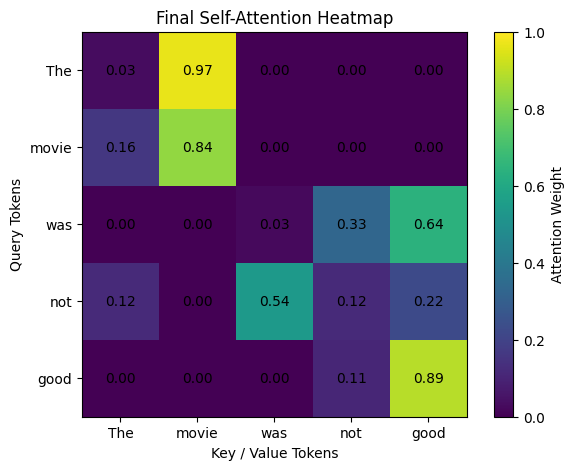

Shape of A_new: (5, 5)
Row sums: [1. 1. 1. 1. 1.]


In [ ]:
plt.figure(figsize=(7, 5))

plt.imshow(A_new, cmap="viridis", vmin=0, vmax=1)
plt.colorbar(label="Attention Weight")

plt.xticks(range(len(tokens)), tokens)
plt.yticks(range(len(tokens)), tokens)

plt.xlabel("Key / Value Tokens")
plt.ylabel("Query Tokens")
plt.title("Final Self-Attention Heatmap")

for i in range(len(tokens)):
    for j in range(len(tokens)):
        plt.text(j, i, f"{A_new[i, j]:.2f}", ha="center", va="center")

plt.show()

print("Shape of A_new:", A_new.shape)
print("Row sums:", np.sum(A_new, axis=1))

## Observation

We wrapped the full self-attention computation into one function.

The complete flow is:

$$
X
\rightarrow
Q,K,V
\rightarrow
S
\rightarrow
S_{\text{scaled}}
\rightarrow
A
\rightarrow
Z
$$

---

### Shape Flow

For our toy sentence:

$$
X \in \mathbb{R}^{5 \times 4}
$$

$$
Q,K,V \in \mathbb{R}^{5 \times 3}
$$

$$
S \in \mathbb{R}^{5 \times 5}
$$

$$
S_{\text{scaled}} \in \mathbb{R}^{5 \times 5}
$$

$$
A \in \mathbb{R}^{5 \times 5}
$$

$$
Z \in \mathbb{R}^{5 \times 3}
$$

---

### Core Understanding

Self-attention does three major things:

1. Computes token-to-token compatibility using $QK^\top$
2. Converts compatibility scores into attention weights using scaled softmax
3. Produces contextual token representations using $AV$

---

### Key Takeaway

The output $Z$ is not a collection of isolated token vectors.

Each row of $Z$ is a context-aware token representation.

## Bridge to Multi-Head Attention

Today, we used one set of projection matrices:

$$
W_Q, W_K, W_V
$$

This gives one attention view of the sentence.

---

### But Language Has Multiple Relationships

In a sentence, different kinds of relationships may exist at the same time:

- Negation relationship: "not" modifies "good"
- Subject relationship: "movie" is the thing being described
- Local phrase structure: "not good"
- Global sentence-level sentiment

A single attention head may not capture all these relationships effectively.

---

### Main Idea of Multi-Head Attention

Instead of computing attention once, we compute attention multiple times in parallel.

Each head has its own projection matrices:

$$
W_Q^{(h)}, W_K^{(h)}, W_V^{(h)}
$$

Each head learns a different type of relationship.

---

### Preview Formula

For head $h$:

$$
\text{head}_h
=
\mathrm{Attention}
\left(
XW_Q^{(h)},
XW_K^{(h)},
XW_V^{(h)}
\right)
$$

Then all heads are combined.

---

### What Comes Next

In the next lecture, we will study:

- Why multiple attention heads are useful
- How each head has separate projection matrices
- How heads are concatenated
- Why output projection $W_O$ is needed
- Shape flow of multi-head attention